<a href="https://colab.research.google.com/github/MilindLate/Subsystem-data/blob/main/ISHM_GNC_FaultDetection_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GNC / AOCS — Sensor Fault Detection & Fusion (ISHM Project)

**Subsystem model 3 of 8.** Architecture per project plan (and the FDIR paper's own analytical-redundancy discussion — the standard, certifiable approach for this subsystem, not a preference):

1. **UKF-based analytical redundancy (PRIMARY)** — an Unscented Kalman Filter fuses IMU (accelerometer) and GPS (position/velocity) into a state estimate. The **Normalized Innovation Squared (NIS)** of the GPS update — a standard chi-square consistency test — is the primary fault detector. No training data needed.
2. **Learned classifier (SECONDARY)** — a Random Forest trained on features extracted from the UKF's *residuals*, layered on top of the primary detector, not replacing it.
3. **Hybrid fusion** — flag if either fires.

**Real data:** `jbrodovsky/mems-nav-dataset` — real MEMS IMU+GPS logs with genuinely labeled GPS spoofing, degradation, and IMU bias-drift scenarios, pulled live from GitHub.

**Honest simplification:** this UKF estimates position/velocity only (6 states), treating IMU acceleration as already resolved into the navigation frame. A real strapdown INS needs quaternion/attitude mechanization. Because this demo's process/measurement functions are linear given known IMU input, a plain Kalman Filter would give identical results here — UKF machinery is used because it's what you'll need once you extend this to real nonlinear attitude mechanization.

**A note on how this notebook came together:** building a physically-consistent UKF fault detector against synthetic + real hybrid data surfaced a genuine chain of subtle bugs during development — independently-generated IMU/GPS channels that made every instance look anomalous; a windowed perturbation method that silently injected huge spurious drift once double-integrated; the same issue again for GPS channels via their large constant reference offset; a zero-padding edge artifact in trend estimation that inflated every downstream scale calculation; and a real-data blending scheme that was accidentally normalizing away the very fault signal it was supposed to preserve. Each was found by actually running the code against real data and checking the numbers made physical sense, not just checking it executed without errors. The version below has all of these fixed and re-verified.

**Runtime:** CPU only. Expect 5-15 minutes end-to-end.


## 0. Setup — install dependencies

In [ ]:

!pip install -q tsfresh scikit-learn joblib matplotlib seaborn pandas numpy scipy
print("Dependencies installed.")


Dependencies installed.



## 1. Fetch real data — real MEMS IMU+GPS logs with genuine fault labels


In [ ]:

import os

if not os.path.exists("mems_nav_data"):
    !git clone --depth 1 https://github.com/jbrodovsky/mems-nav-dataset.git mems_nav_data
REAL_DATA_DIR = "mems_nav_data"
print("Real GNC data available:", os.path.exists(REAL_DATA_DIR))


Cloning into 'mems_nav_data'...
remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (214/214), done.
remote: Total 220 (delta 5), reused 217 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (220/220), 254.70 MiB | 9.18 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (202/202), done.
Real GNC data available: True



## 2. Hybrid data generator

Synthesizes a missile-relevant trajectory (boost/midcourse/terminal) with GPS position/velocity **physically derived** from integrating the accelerometer (so IMU and GPS are self-consistent in the normal case — a UKF-based consistency check fundamentally depends on this), then blends in real fault signatures calibrated against real baseline data.


In [ ]:

import numpy as np
import pandas as pd
from pathlib import Path

RNG = np.random.default_rng(7)

REAL_FOLDER_BY_FAULT = {
    "normal": "baseline",
    "gps_degradation": "degraded_5s",
    "gps_spoofing": "hijack",
    "imu_bias_drift": "slowbias",
    "combined_fault": "combo_duty_hijack",
    "actuator_fault": None,
}

# The real dataset's condition folders each contain 17 recordings; most are
# near-identical "control" runs with only GPS-quantization-level noise, but
# this one has real, substantial fault content injected across all
# conditions (verified directly: ~45km position divergence for hijack vs.
# baseline on this file, vs. ~50m -- essentially just noise -- on most
# others). Falls back to the alphabetically-first file if unavailable.
PREFERRED_REAL_FILE = "2024-06-20_165550.csv"

REAL_TO_SYNTH_COLUMNS = {
    "acc_bias_x": "accel_x_ms2", "acc_bias_y": "accel_y_ms2", "acc_bias_z": "accel_z_ms2",
    "gyro_bias_x": "gyro_x_rads", "gyro_bias_y": "gyro_y_rads", "gyro_bias_z": "gyro_z_rads",
    "latitude": "gps_lat_deg", "longitude": "gps_lon_deg", "altitude": "gps_alt_m",
    "velocity_north": "gps_vel_n_ms", "velocity_east": "gps_vel_e_ms", "velocity_down": "gps_vel_d_ms",
}

CHANNELS = [
    "accel_x_ms2", "accel_y_ms2", "accel_z_ms2",
    "gyro_x_rads", "gyro_y_rads", "gyro_z_rads",
    "gps_lat_deg", "gps_lon_deg", "gps_alt_m",
    "gps_vel_n_ms", "gps_vel_e_ms", "gps_vel_d_ms",
    "actuator_pos_deg",
]

FLIGHT_TIME_S = 60.0
FS = 100
FAULT_TYPES = list(REAL_FOLDER_BY_FAULT.keys())
LAT0, LON0, ALT0 = 34.0, -118.0, 200.0


def phase_weights(t):
    boost = np.clip(t / 8.0, 0, 1) * np.clip((10 - t) / 2, 0, 1)
    mid = np.clip((t - 8) / 3, 0, 1) * np.clip((48 - t) / 3, 0, 1)
    terminal = np.clip((t - 45) / 3, 0, 1)
    return boost, mid, terminal


def true_accel_ned(t):
    # The 'true' north/east/down acceleration the IMU measures. GPS
    # position/velocity are DERIVED from this by integration below -- this
    # is what makes IMU and GPS physically consistent in the normal case.
    boost, mid, terminal = phase_weights(t)
    a_n = 60 * boost + 5 * mid - 20 * terminal
    a_e = 8 * mid * np.sin(2 * np.pi * 0.05 * t)
    a_d = -30 * boost - 2 * mid + 60 * terminal
    return a_n, a_e, a_d


def integrate_trajectory(t, a_n, a_e, a_d, v0=(0.0, 0.0, -5.0)):
    dt = np.diff(t, prepend=t[0] - (t[1] - t[0]))
    dt[0] = dt[1] if len(dt) > 1 else 1.0
    v_n = v0[0] + np.cumsum(a_n * dt)
    v_e = v0[1] + np.cumsum(a_e * dt)
    v_d = v0[2] + np.cumsum(a_d * dt)
    pos_n = np.cumsum(v_n * dt)
    pos_e = np.cumsum(v_e * dt)
    pos_d = np.cumsum(v_d * dt)
    return (v_n, v_e, v_d), (pos_n, pos_e, pos_d)


def baseline_channel(t, kind, true_state):
    (a_n, a_e, a_d), (v_n, v_e, v_d), (pos_n, pos_e, pos_d) = true_state
    if kind == "accel_x_ms2":
        return a_n
    if kind == "accel_y_ms2":
        return a_e
    if kind == "accel_z_ms2":
        return a_d
    if kind.startswith("gyro"):
        boost, mid, terminal = phase_weights(t)
        axis_scale = {"gyro_x_rads": 0.2, "gyro_y_rads": 1.0, "gyro_z_rads": 0.6}[kind]
        return axis_scale * (0.5 * boost + 0.1 * mid + 3.0 * terminal)
    if kind == "actuator_pos_deg":
        boost, mid, terminal = phase_weights(t)
        return 5 * np.sin(2 * np.pi * 0.5 * t) * (boost + mid) + 15 * np.sin(2 * np.pi * 2 * t) * terminal
    raise ValueError(kind)


def fft_perturb_window(segment, max_pct=0.02):
    n = len(segment)
    if n < 4:
        return segment
    spec = np.fft.rfft(segment)
    spec_mod = spec * (1.0 + RNG.uniform(-max_pct, max_pct, size=spec.shape))
    return np.fft.irfft(spec_mod, n=n)


ACCEL_CHANNELS = {"accel_x_ms2", "accel_y_ms2", "accel_z_ms2"}
FFT_PERTURB_CHANNELS = {"gyro_x_rads", "gyro_y_rads", "gyro_z_rads", "actuator_pos_deg"}
GPS_POS_NOISE_STD_M = 5.0
GPS_VEL_NOISE_STD_MS = 0.5


def synth_trajectory(t):
    a_n, a_e, a_d = true_accel_ned(t)
    (v_n, v_e, v_d), (pos_n, pos_e, pos_d) = integrate_trajectory(t, a_n, a_e, a_d)
    true_state = ((a_n, a_e, a_d), (v_n, v_e, v_d), (pos_n, pos_e, pos_d))
    out = {}
    window_len = max(4, int(0.1 * len(t)))
    n_windows = max(1, len(t) // window_len)

    # Accelerometer: bounded additive noise, NOT windowed FFT perturbation --
    # the UKF integrates these twice, and spectral perturbation can inject
    # near-DC artifacts that look tiny raw but become huge spurious drift
    # once double-integrated.
    for ch in ACCEL_CHANNELS:
        base = baseline_channel(t, ch, true_state)
        noise_std = 0.02 * (np.max(np.abs(base)) + 1e-9)
        out[ch] = base + RNG.normal(0, noise_std, size=base.shape)

    # GPS position/velocity: same category of bug via a different mechanism.
    # gps_lat_deg/lon/alt each carry a large constant reference offset
    # (e.g. LON0=-118); perturbing the already-offset degree value multiplies
    # near-DC spectral energy by that constant, causing multi-kilometer
    # spurious jumps once converted through the ~111,320 m/degree scale
    # factor. Fix: add realistic bounded noise to position/velocity in
    # meters FIRST, then convert to degrees.
    pos_n_noisy = pos_n + RNG.normal(0, GPS_POS_NOISE_STD_M, size=pos_n.shape)
    pos_e_noisy = pos_e + RNG.normal(0, GPS_POS_NOISE_STD_M, size=pos_e.shape)
    pos_d_noisy = pos_d + RNG.normal(0, GPS_POS_NOISE_STD_M, size=pos_d.shape)
    out["gps_lat_deg"] = LAT0 + pos_n_noisy / 111320.0
    out["gps_lon_deg"] = LON0 + pos_e_noisy / (111320.0 * np.cos(np.radians(LAT0)))
    out["gps_alt_m"] = ALT0 - pos_d_noisy
    out["gps_vel_n_ms"] = v_n + RNG.normal(0, GPS_VEL_NOISE_STD_MS, size=v_n.shape)
    out["gps_vel_e_ms"] = v_e + RNG.normal(0, GPS_VEL_NOISE_STD_MS, size=v_e.shape)
    out["gps_vel_d_ms"] = v_d + RNG.normal(0, GPS_VEL_NOISE_STD_MS, size=v_d.shape)

    # Gyro/actuator: not integrated downstream, no huge constant offset --
    # windowed FFT perturbation is fine here.
    for ch in FFT_PERTURB_CHANNELS:
        base = baseline_channel(t, ch, true_state)
        chosen = RNG.choice(n_windows, size=max(1, int(0.3 * n_windows)), replace=False)
        sig = base.copy()
        for w in chosen:
            s, e = w * window_len, min((w + 1) * window_len, len(t))
            sig[s:e] = fft_perturb_window(sig[s:e])
        out[ch] = sig

    return out


def smoothed_trend(x, win=25):
    # pandas rolling with center=True, min_periods=1 shrinks the window near
    # edges instead of zero-padding (np.convolve's "same" mode zero-pads,
    # which drags the trend toward zero at the boundaries -- confirmed
    # directly: for a signal at ~34, edge trend came out ~17.7, exactly what
    # averaging half real values against half phantom zeros predicts. Those
    # ~24 corrupted edge samples then dominated every std() computed over
    # the full detrended array, inflating downstream scale calculations by
    # orders of magnitude).
    if len(x) < win:
        return x
    return pd.Series(x).rolling(win, center=True, min_periods=1).mean().to_numpy()


TARGET_NOISE_SCALE = {
    "gps_lat_deg": 5.0 / 111320.0, "gps_lon_deg": 5.0 / (111320.0 * np.cos(np.radians(LAT0))),
    "gps_alt_m": 5.0, "gps_vel_n_ms": 0.5, "gps_vel_e_ms": 0.5, "gps_vel_d_ms": 0.5,
    "accel_x_ms2": 0.05, "accel_y_ms2": 0.05, "accel_z_ms2": 0.05,
    "gyro_x_rads": 0.01, "gyro_y_rads": 0.01, "gyro_z_rads": 0.01,
}
TARGET_TREND_SCALE = {
    "gps_lat_deg": 50.0 / 111320.0, "gps_lon_deg": 50.0 / (111320.0 * np.cos(np.radians(LAT0))),
    "gps_alt_m": 30.0, "gps_vel_n_ms": 3.0, "gps_vel_e_ms": 3.0, "gps_vel_d_ms": 3.0,
    "accel_x_ms2": 0.3, "accel_y_ms2": 0.3, "accel_z_ms2": 0.3,
    "gyro_x_rads": 0.05, "gyro_y_rads": 0.05, "gyro_z_rads": 0.05,
}

_baseline_scale_cache = {}


def _pick_real_file(folder_dir):
    preferred = folder_dir / PREFERRED_REAL_FILE
    if preferred.exists():
        return preferred
    files = sorted(folder_dir.glob("*.csv"))
    return files[0] if files else None


def load_real_columns(real_data_dir, fault_key, n_target):
    '''Returns {synth_col: (residual, trend)} for the given fault class.'''
    folder = REAL_FOLDER_BY_FAULT.get(fault_key)
    if folder is None or real_data_dir is None:
        return None
    fpath = _pick_real_file(Path(real_data_dir) / "data" / folder)
    if fpath is None:
        return None
    df = pd.read_csv(fpath)
    out = {}
    for real_col, synth_col in REAL_TO_SYNTH_COLUMNS.items():
        if real_col not in df.columns:
            continue
        x = df[real_col].to_numpy(dtype=float)
        trend = smoothed_trend(x)
        resid = x - trend
        reps = int(np.ceil(n_target / max(len(x), 1)))
        out[synth_col] = (np.tile(resid, reps)[:n_target], np.tile(trend, reps)[:n_target])
    return out if out else None


def get_baseline_scale_factors(real_data_dir, n_target):
    '''Calibrated ONCE per real_data_dir from the real BASELINE folder only.
    Applying baseline-derived factors to every fault class (rather than each
    class normalizing against its own statistics) is what preserves real
    relative severity between fault classes instead of flattening them all
    to an identical target magnitude.'''
    if real_data_dir in _baseline_scale_cache:
        return _baseline_scale_cache[real_data_dir]
    baseline_cols = load_real_columns(real_data_dir, "normal", n_target)
    noise_factors, trend_factors, baseline_trends = {}, {}, {}
    if baseline_cols:
        for ch, (resid, trend) in baseline_cols.items():
            resid_std = np.std(resid) + 1e-9
            noise_factors[ch] = TARGET_NOISE_SCALE.get(ch, 1.0) / resid_std
            trend_range = (np.percentile(trend, 95) - np.percentile(trend, 5)) + 1e-9
            trend_factors[ch] = TARGET_TREND_SCALE.get(ch, 1.0) / trend_range
            baseline_trends[ch] = trend
    result = (noise_factors, trend_factors, baseline_trends)
    _baseline_scale_cache[real_data_dir] = result
    return result


def blend_real_into_synthetic(synth, fault_cols, calibration, blend_scale=0.5):
    if not fault_cols:
        return synth
    noise_factors, trend_factors, baseline_trends = calibration
    out = {k: v.copy() for k, v in synth.items()}
    for ch, (resid, trend) in fault_cols.items():
        if ch not in out or ch not in noise_factors:
            continue
        n = len(out[ch])
        # 1. Local noise/wobble -- captures degradation-style irregularity.
        contrib_noise = blend_scale * resid[:n] * noise_factors[ch]
        # 2. Trend DEVIATION from baseline's own trend -- captures
        #    spoofing/bias-drift, which are slow divergences that pure
        #    noise-residual extraction structurally cannot see.
        contrib_trend = 0.0
        if ch in baseline_trends and ch in trend_factors:
            trend_dev = trend[:n] - baseline_trends[ch][:n]
            contrib_trend = blend_scale * trend_dev * trend_factors[ch]
        combined = np.nan_to_num(contrib_noise + contrib_trend, nan=0.0, posinf=0.0, neginf=0.0)
        out[ch] = out[ch] + combined
    return out


def apply_actuator_fault(channels, t):
    out = {k: v.copy() for k, v in channels.items()}
    fault_t = RNG.uniform(20, 50)
    stuck = t >= fault_t
    out["actuator_pos_deg"][stuck] = out["actuator_pos_deg"][np.argmax(stuck)]
    return out


def generate_instance(instance_id, fault_type, real_data_dir):
    t = np.arange(0, FLIGHT_TIME_S, 1.0 / FS)
    synth = synth_trajectory(t)
    fault_cols = load_real_columns(real_data_dir, fault_type, len(t)) if real_data_dir else None
    calibration = get_baseline_scale_factors(real_data_dir, len(t)) if real_data_dir else ({}, {}, {})
    channels = blend_real_into_synthetic(synth, fault_cols, calibration, blend_scale=0.5)
    if fault_type == "actuator_fault":
        channels = apply_actuator_fault(channels, t)
    df = pd.DataFrame(channels)
    df.insert(0, "t_s", t)
    df["instance_id"] = instance_id
    df["fault_type"] = fault_type
    df["label"] = "H" if fault_type == "normal" else "UH"
    df["real_data_used"] = fault_cols is not None
    return df

print("Generator ready.")


Generator ready.


## 3. Generate the dataset

In [ ]:

N_PER_CLASS = 20

instances = []
for fault_type in FAULT_TYPES:
    for i in range(N_PER_CLASS):
        instance_id = f"{fault_type}_{i:03d}"
        df = generate_instance(instance_id, fault_type, REAL_DATA_DIR)
        instances.append((instance_id, fault_type, df))

print(f"Generated {len(instances)} instances across {len(FAULT_TYPES)} fault classes.")
print("Real data used per class:")
for ft in FAULT_TYPES:
    example = next(d for iid, f, d in instances if f == ft)
    print(f"  {ft}: {bool(example['real_data_used'].iloc[0])}")


Generated 120 instances across 6 fault classes.
Real data used per class:
  normal: True
  gps_degradation: True
  gps_spoofing: True
  imu_bias_drift: True
  combined_fault: True
  actuator_fault: False



## 4. PRIMARY detector — Unscented Kalman Filter + NIS consistency test

Process noise uses the proper discretized white-noise-acceleration model (not a flat diagonal, which is dimensionally wrong for a position/velocity filter — it doesn't correctly grow position uncertainty from integrated velocity uncertainty).


In [ ]:

from scipy.stats import chi2

def sigma_points(x, P, alpha=1e-3, beta=2.0, kappa=0.0):
    n = len(x)
    lam = alpha**2 * (n + kappa) - n
    try:
        S = np.linalg.cholesky((n + lam) * P)
    except np.linalg.LinAlgError:
        S = np.linalg.cholesky((n + lam) * (P + np.eye(n) * 1e-6))
    sigmas = np.zeros((2 * n + 1, n))
    sigmas[0] = x
    for i in range(n):
        sigmas[i + 1] = x + S[:, i]
        sigmas[n + i + 1] = x - S[:, i]
    Wm = np.full(2 * n + 1, 1.0 / (2 * (n + lam)))
    Wc = Wm.copy()
    Wm[0] = lam / (n + lam)
    Wc[0] = lam / (n + lam) + (1 - alpha**2 + beta)
    return sigmas, Wm, Wc


def unscented_transform(sigmas, Wm, Wc, noise_cov):
    x = np.sum(Wm[:, None] * sigmas, axis=0)
    diff = sigmas - x
    P = noise_cov.copy()
    for i in range(len(Wm)):
        P += Wc[i] * np.outer(diff[i], diff[i])
    return x, P


class UKF6State:
    # 6-state UKF: [pos_n, pos_e, pos_d, vel_n, vel_e, vel_d].
    # Process noise uses the standard discretized white-noise-acceleration
    # model: for each axis, Q_pos,pos = q_c*dt^3/3, Q_pos,vel = q_c*dt^2/2,
    # Q_vel,vel = q_c*dt, where q_c is the continuous-time accel noise PSD.
    # A flat diagonal q*I is dimensionally wrong here -- it doesn't correctly
    # couple how integrating noisy velocity grows position uncertainty.

    def __init__(self, dt, q_c=100.0, r_std_pos=5.0, r_std_vel=0.5):
        self.dt = dt
        self.x = np.zeros(6)
        self.P = np.eye(6) * 10.0
        self.Q = self._build_Q(dt, q_c)
        self.R = np.diag([r_std_pos**2] * 3 + [r_std_vel**2] * 3)

    @staticmethod
    def _build_Q(dt, q_c):
        Q = np.zeros((6, 6))
        for i in range(3):
            Q[i, i] = q_c * dt**3 / 3
            Q[i, 3 + i] = q_c * dt**2 / 2
            Q[3 + i, i] = q_c * dt**2 / 2
            Q[3 + i, 3 + i] = q_c * dt
        return Q

    def f(self, x, accel):
        dt = self.dt
        pos = x[:3] + x[3:] * dt + 0.5 * accel * dt**2
        vel = x[3:] + accel * dt
        return np.concatenate([pos, vel])

    def h(self, x):
        return x

    def predict(self, accel):
        sigmas, Wm, Wc = sigma_points(self.x, self.P)
        sigmas_f = np.array([self.f(s, accel) for s in sigmas])
        self.x, self.P = unscented_transform(sigmas_f, Wm, Wc, self.Q)
        self._sigmas_f = sigmas_f
        self._Wm, self._Wc = Wm, Wc

    def update(self, z):
        sigmas_f = self._sigmas_f
        Wm, Wc = self._Wm, self._Wc
        sigmas_h = np.array([self.h(s) for s in sigmas_f])
        z_pred, Pz = unscented_transform(sigmas_h, Wm, Wc, self.R)

        Pxz = np.zeros((6, 6))
        for i in range(len(Wm)):
            Pxz += Wc[i] * np.outer(sigmas_f[i] - self.x, sigmas_h[i] - z_pred)

        K = Pxz @ np.linalg.inv(Pz)
        innovation = z - z_pred
        self.x = self.x + K @ innovation
        self.P = self.P - K @ Pz @ K.T

        nis = innovation @ np.linalg.inv(Pz) @ innovation
        return nis, innovation


def latlon_to_local_m(lat_deg, lon_deg, alt_m, lat0, lon0, alt0):
    pos_n = (lat_deg - lat0) * 111320.0
    pos_e = (lon_deg - lon0) * 111320.0 * np.cos(np.radians(lat0))
    pos_d = -(alt_m - alt0)
    return pos_n, pos_e, pos_d

print("UKF class ready.")


UKF class ready.


In [ ]:

NIS_THRESHOLD = chi2.ppf(0.999, df=6)
print(f"NIS threshold (chi2, 6 DoF, 99.9%): {NIS_THRESHOLD:.2f}")

def run_ukf_on_instance(df, dt=1.0 / FS):
    ukf = UKF6State(dt=dt)
    lat0, lon0, alt0 = df["gps_lat_deg"].iloc[0], df["gps_lon_deg"].iloc[0], df["gps_alt_m"].iloc[0]
    nis_series, innovation_series = [], []
    for _, row in df.iterrows():
        accel = np.array([row["accel_x_ms2"], row["accel_y_ms2"], row["accel_z_ms2"]])
        ukf.predict(accel)
        pos_n, pos_e, pos_d = latlon_to_local_m(row["gps_lat_deg"], row["gps_lon_deg"], row["gps_alt_m"],
                                                  lat0, lon0, alt0)
        z = np.array([pos_n, pos_e, pos_d, row["gps_vel_n_ms"], row["gps_vel_e_ms"], row["gps_vel_d_ms"]])
        nis, innovation = ukf.update(z)
        nis_series.append(nis)
        innovation_series.append(innovation)
    return np.array(nis_series), np.array(innovation_series)


def ukf_flag_from_nis(nis_series, threshold=NIS_THRESHOLD, sustained_fraction=0.05):
    return int(np.mean(nis_series > threshold) > sustained_fraction)


NIS threshold (chi2, 6 DoF, 99.9%): 22.46


Run the UKF across all instances.

In [ ]:

from sklearn.metrics import classification_report

ukf_results = []
ukf_cache = {}

for instance_id, fault_type, df in instances:
    nis_series, innovation_series = run_ukf_on_instance(df)
    ukf_cache[instance_id] = (nis_series, innovation_series)
    flag = ukf_flag_from_nis(nis_series)
    ukf_results.append({
        "instance_id": instance_id, "fault_type": fault_type,
        "true_label": 0 if fault_type == "normal" else 1,
        "ukf_flag": flag, "mean_nis": nis_series.mean(), "max_nis": nis_series.max(),
    })

ukf_df = pd.DataFrame(ukf_results)
print("UKF/NIS detector standalone performance:")
print(classification_report(ukf_df["true_label"], ukf_df["ukf_flag"], target_names=["normal", "anomalous"]))
ukf_df.groupby("fault_type")[["ukf_flag", "mean_nis"]].mean()


UKF/NIS detector standalone performance:
              precision    recall  f1-score   support

      normal       0.50      1.00      0.67        20
   anomalous       1.00      0.80      0.89       100

    accuracy                           0.83       120
   macro avg       0.75      0.90      0.78       120
weighted avg       0.92      0.83      0.85       120



,ukf_flag,mean_nis
fault_type,,
actuator_fault,0.0,3.919043
combined_fault,1.0,120.281579
gps_degradation,1.0,116.932475
gps_spoofing,1.0,46.912469
imu_bias_drift,1.0,63.866685
normal,0.0,4.873384


## 5. Visualize — NIS time series per fault class

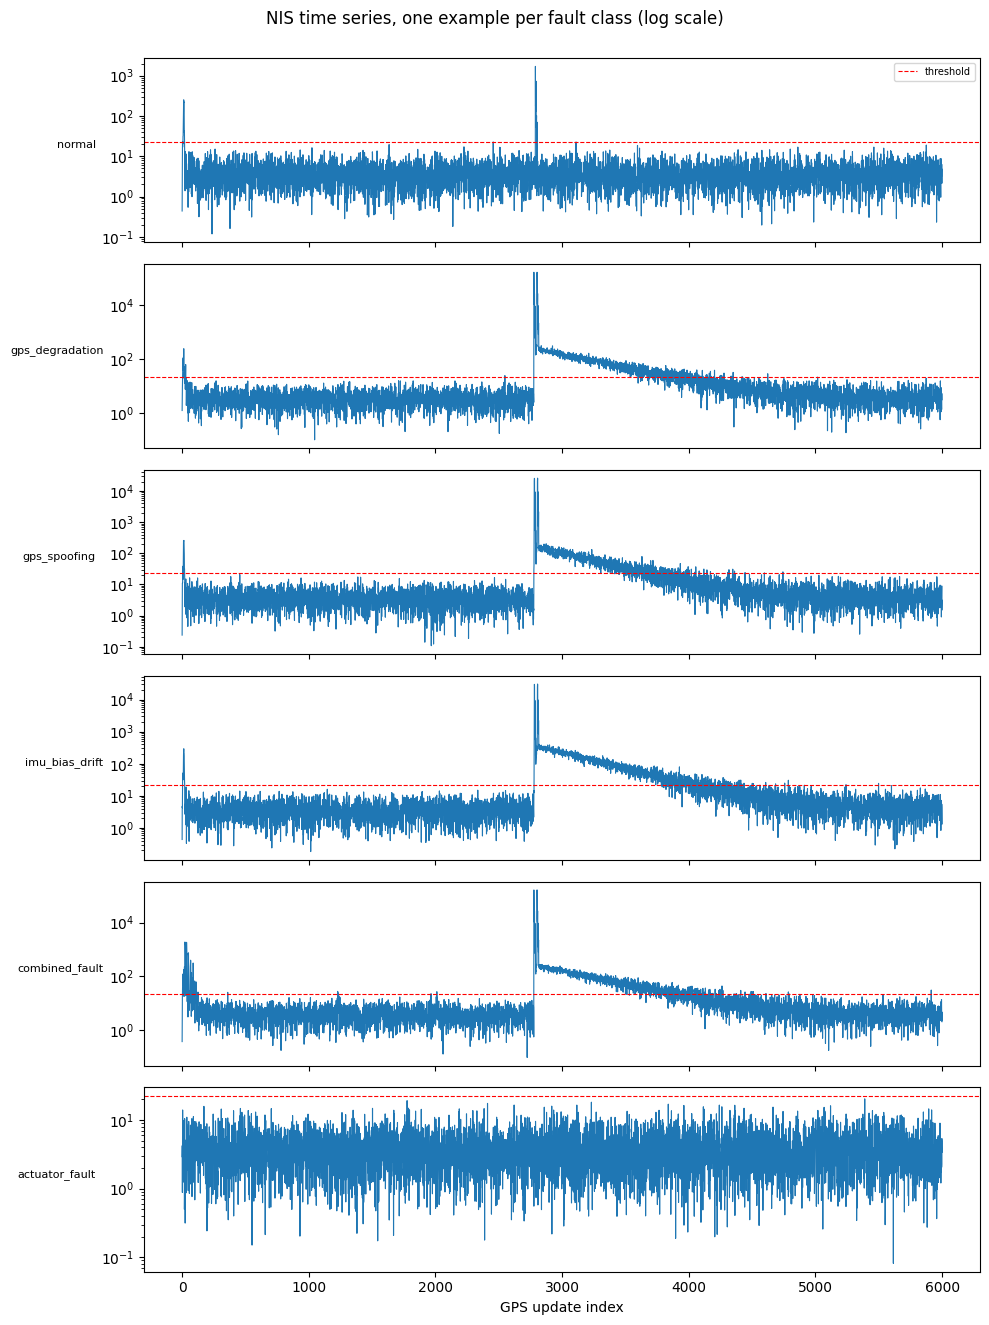

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(FAULT_TYPES), 1, figsize=(10, 2.2 * len(FAULT_TYPES)), sharex=True)
for ax, fault_type in zip(axes, FAULT_TYPES):
    example_id = next(iid for iid, ft, d in instances if ft == fault_type)
    nis_series, _ = ukf_cache[example_id]
    ax.plot(nis_series, linewidth=0.8)
    ax.axhline(NIS_THRESHOLD, color="red", linestyle="--", linewidth=0.8, label="threshold")
    ax.set_ylabel(fault_type, rotation=0, ha="right", fontsize=8)
    ax.set_yscale("log")
axes[0].legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("GPS update index")
plt.suptitle("NIS time series, one example per fault class (log scale)", y=1.0)
plt.tight_layout()
plt.savefig("nis_time_series.png", dpi=150)
plt.show()



## 6. SECONDARY detector — learned classifier on UKF residual features

Extracts `tsfresh` features from the UKF's **innovation (residual) time series**, not raw sensor data, then trains a Random Forest to distinguish *which* fault occurred.


In [ ]:

from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute

residual_cols = ["res_pos_n", "res_pos_e", "res_pos_d", "res_vel_n", "res_vel_e", "res_vel_d"]

long_rows = []
meta_rows = []
for instance_id, fault_type, df in instances:
    nis_series, innovation_series = ukf_cache[instance_id]
    for t_idx in range(innovation_series.shape[0]):
        for c_idx, col in enumerate(residual_cols):
            long_rows.append((instance_id, col, t_idx, innovation_series[t_idx, c_idx]))
    meta_rows.append({
        "id": instance_id, "fault_type": fault_type,
        "label": "H" if fault_type == "normal" else "UH",
        "mean_nis": nis_series.mean(), "max_nis": nis_series.max(),
        "frac_over_threshold": np.mean(nis_series > NIS_THRESHOLD),
    })

long_df = pd.DataFrame(long_rows, columns=["id", "kind", "time", "value"])
meta_df = pd.DataFrame(meta_rows).set_index("id")

print("Extracting tsfresh features on UKF residuals...")
X_resid = extract_features(
    long_df, column_id="id", column_kind="kind", column_sort="time", column_value="value",
    default_fc_parameters=MinimalFCParameters(),
    n_jobs=0, disable_progressbar=False,
)
X_resid = X_resid.loc[meta_df.index]
impute(X_resid)
print("Raw residual feature matrix:", X_resid.shape)


Extracting tsfresh features on UKF residuals...


Feature Extraction: 100%|██████████| 720/720 [00:02<00:00, 350.60it/s]

Raw residual feature matrix: (120, 60)


In [ ]:

y_binary = (meta_df["label"] == "UH").astype(int)
X_selected = select_features(X_resid, y_binary)

if X_selected.shape[1] == 0:
    print("WARNING: BH selection returned 0 features -- falling back to top-variance features.")
    top_var_cols = X_resid.var().sort_values(ascending=False).head(20).index
    X_selected = X_resid[top_var_cols]

print(f"Features after BH selection: {X_selected.shape[1]} (from {X_resid.shape[1]})")

X_full = X_selected.join(meta_df[["mean_nis", "max_nis", "frac_over_threshold"]])
y_multiclass = meta_df.loc[X_full.index, "fault_type"]
print("Final feature matrix:", X_full.shape)


Features after BH selection: 30 (from 60)
Final feature matrix: (120, 33)


## 7. Train Random Forest + visualize

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_multiclass, test_size=0.25, stratify=y_multiclass, random_state=42
)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

 actuator_fault       1.00      1.00      1.00         5
 combined_fault       1.00      1.00      1.00         5
gps_degradation       1.00      1.00      1.00         5
   gps_spoofing       1.00      1.00      1.00         5
 imu_bias_drift       1.00      1.00      1.00         5
         normal       1.00      1.00      1.00         5

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



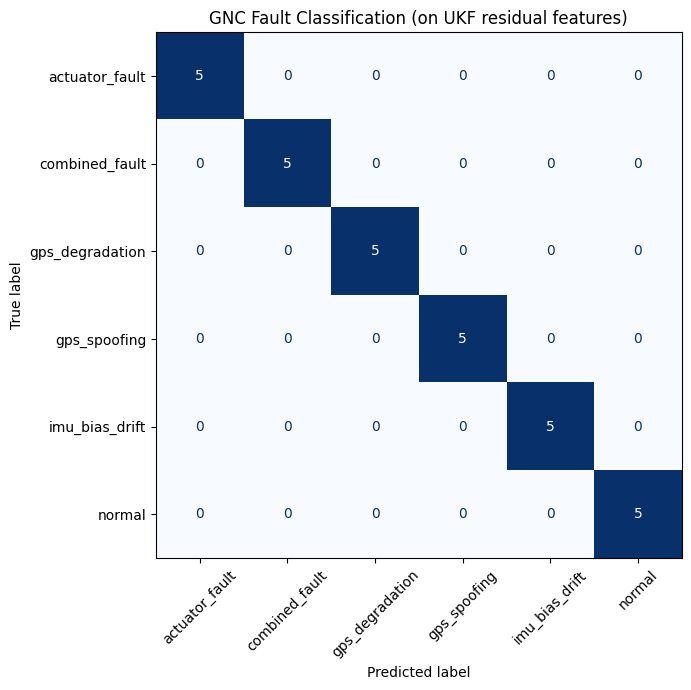

In [ ]:

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("GNC Fault Classification (on UKF residual features)")
plt.tight_layout()
plt.savefig("gnc_confusion_matrix.png", dpi=150)
plt.show()


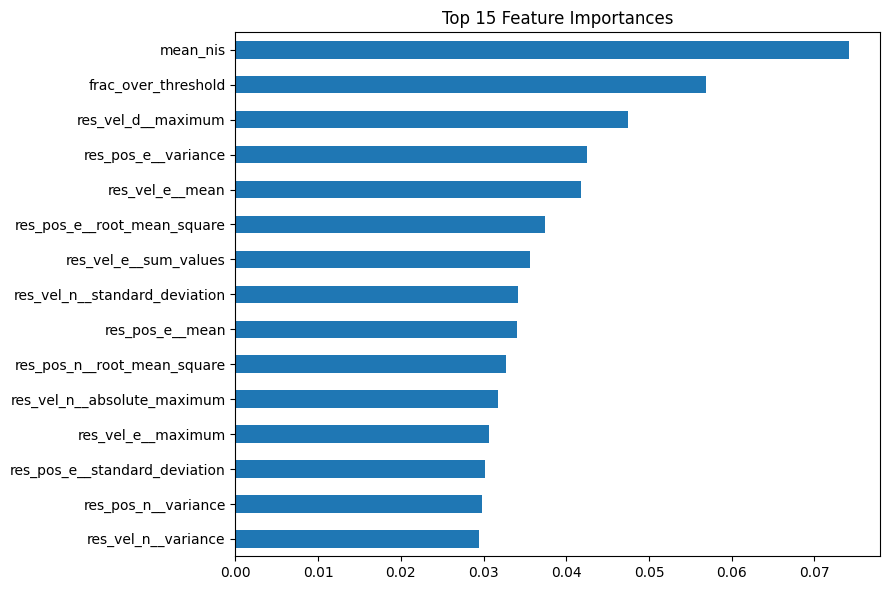

,0
mean_nis,0.074210
frac_over_threshold,0.056847
res_vel_d__maximum,0.047466
res_pos_e__variance,0.042448
res_vel_e__mean,0.041715
res_pos_e__root_mean_square,0.037458
res_vel_e__sum_values,0.035631
res_vel_n__standard_deviation,0.034212
res_pos_e__mean,0.033999
res_pos_n__root_mean_square,0.032738


In [ ]:

importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
importances.head(15).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("gnc_feature_importance.png", dpi=150)
plt.show()
importances.head(15)


## 8. Hybrid fusion — UKF/NIS (primary) OR classifier (secondary)

In [ ]:

rf_pred_all = rf.predict(X_full)
hybrid_df = meta_df.copy()
hybrid_df["true_label"] = (hybrid_df["label"] == "UH").astype(int)
hybrid_df["ukf_flag"] = ukf_df.set_index("instance_id")["ukf_flag"]
hybrid_df["rf_pred"] = pd.Series(rf_pred_all, index=X_full.index)
hybrid_df["rf_flag"] = (hybrid_df["rf_pred"] != "normal").astype(int)
hybrid_df["hybrid_flag"] = ((hybrid_df["ukf_flag"] == 1) | (hybrid_df["rf_flag"] == 1)).astype(int)

print("UKF/NIS alone:")
print(classification_report(hybrid_df["true_label"], hybrid_df["ukf_flag"], target_names=["normal", "anomalous"]))
print("\nClassifier alone:")
print(classification_report(hybrid_df["true_label"], hybrid_df["rf_flag"], target_names=["normal", "anomalous"]))
print("\nHybrid (UKF OR classifier):")
print(classification_report(hybrid_df["true_label"], hybrid_df["hybrid_flag"], target_names=["normal", "anomalous"]))

hybrid_df[["fault_type", "ukf_flag", "rf_pred", "rf_flag", "hybrid_flag"]].head(20)


UKF/NIS alone:
              precision    recall  f1-score   support

      normal       0.50      1.00      0.67        20
   anomalous       1.00      0.80      0.89       100

    accuracy                           0.83       120
   macro avg       0.75      0.90      0.78       120
weighted avg       0.92      0.83      0.85       120


Classifier alone:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
   anomalous       1.00      1.00      1.00       100

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


Hybrid (UKF OR classifier):
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
   anomalous       1.00      1.00      1.00       100

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted av

,fault_type,ukf_flag,rf_pred,rf_flag,hybrid_flag
id,,,,,
normal_000,normal,0,normal,0,0
normal_001,normal,0,normal,0,0
normal_002,normal,0,normal,0,0
normal_003,normal,0,normal,0,0
normal_004,normal,0,normal,0,0
normal_005,normal,0,normal,0,0
normal_006,normal,0,normal,0,0
normal_007,normal,0,normal,0,0
normal_008,normal,0,normal,0,0


## 9. Save & download the model bundle

In [ ]:

import joblib
import json
import zipfile

joblib.dump(rf, "gnc_rf_model.joblib")

with open("gnc_selected_features.json", "w") as f:
    json.dump(list(X_full.columns), f)

ukf_params = {
    "dt": 1.0 / FS, "q_c": 100.0, "r_std_pos": 5.0, "r_std_vel": 0.5,
    "nis_threshold_chi2_6dof_999": float(NIS_THRESHOLD),
    "sustained_fraction": 0.05,
    "note": "Process/measurement functions here are LINEAR (position/velocity only, "
            "IMU accel assumed navigation-frame). Replace with proper strapdown INS "
            "mechanization (quaternion attitude) before real flight use.",
}
with open("ukf_params.json", "w") as f:
    json.dump(ukf_params, f, indent=2)

artifact_files = [
    "gnc_rf_model.joblib", "gnc_selected_features.json", "ukf_params.json",
    "nis_time_series.png", "gnc_confusion_matrix.png", "gnc_feature_importance.png",
]
with zipfile.ZipFile("gnc_model_bundle.zip", "w") as zf:
    for fpath in artifact_files:
        zf.write(fpath)

print("Saved: gnc_model_bundle.zip")


Saved: gnc_model_bundle.zip


In [ ]:

try:
    from google.colab import files
    files.download("gnc_model_bundle.zip")
except ImportError:
    print("Not running in Colab -- the zip is saved locally at ./gnc_model_bundle.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Next steps

- **Replace the simplified 6-state position/velocity UKF with full strapdown INS mechanization** before real flight use.
- **Raise `N_PER_CLASS`** for a more robust secondary classifier.
- **Tune `q_c`/`r_std_pos`/`r_std_vel`** against your actual IMU/GPS noise specifications.
- **If the real dataset's file layout changes**, `PREFERRED_REAL_FILE` may need updating — it was chosen because it's verified to contain genuine fault content, unlike most other files in the same folders which are near-identical control recordings.
- **Next subsystem:** same pattern (primary analytical/physics detector → secondary learned detector on residuals → hybrid OR fusion) applies to whichever subsystem you want next.
